У цьому проєкті я поставив собі за мету проаналізувати результати A/B-тесту, а також побудувати теплову карту утримання (retention heatmap) користувачів за днем реєстрації.
### A/B
Результати тесту виявилися незадовільними та статистично незначущими. Хоча ключова метрика (ARPU) номінально зросла, статистичний аналіз показує, що це зростання є наслідком випадковості. Впровадження цього оновлення є ризикованим і може призвести до реальних фінансових втрат.

Детальніше: у тестовій групі статистично значущо впала конверсія в покупку (CR). Водночас середній дохід на платника (ARPPU) математично зріс, але розрахунки доводять, що це зростання зумовлене випадковими аномальними платежами, а не системним покращенням. Як наслідок, зміна нашої цільової метрики (ARPU) виявилася статистично незначущою.

Висновок: випускати оновлення недоцільно.


Рішення:

Оскільки нашою єдиною цільовою метрикою є ARPU, а CR та ARPPU виступають лише проксі-метриками для пояснення її динаміки, поправки на множинну перевірку гіпотез не застосовувалися.
Статистичне обґрунтування:

- P-value для CR (Хі-квадрат): 0.0365 (статистично значуще падіння). Зниження частки платників не є випадковим.
- P-value ARPPU: 0.1002 статистично незначуще зростання.
- Довірчий інтервал (Confidence Interval) ARPPU: [-66.34, 730.65], надзвичайно широкий розкид. Зміна середнього чека може призвести як до зростання на 730 одиниць, так і до падіння на 66 одиниць на користувача.
- P-value ARPU: 0.5330 (зміна цільової метрики статистично незначуща).
- Довірчий інтервал (Confidence Interval) ARPU: [-3.04, 5.49]. Інтервал перетинає нуль, стійкого фінансового зростання не підтверджено.

# Підключення до даних та завантаження бібліотек

In [49]:
import kagglehub
from pandas import read_csv

# Download latest version
path = kagglehub.dataset_download("debs2x/gamelytics-mobile-analytics-challenge")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\pakma\.cache\kagglehub\datasets\debs2x\gamelytics-mobile-analytics-challenge\versions\2


In [50]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

In [51]:
from scipy.stats import chisquare, chi2_contingency, bootstrap, ttest_ind

In [52]:
df_ab = read_csv(r'.\ab_test.csv', sep=';')
df_ab.head()

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


In [53]:
df_auth = read_csv(r'.\auth_data.csv', sep=';')
df_auth.head()

,auth_ts,uid
0,911382223,1
1,932683089,2
2,932921206,2
3,933393015,2
4,933875379,2


In [54]:
df_reg = read_csv(r'.\reg_data.csv', sep=';')
df_reg.head()

,reg_ts,uid
0,911382223,1
1,932683089,2
2,947802447,3
3,959523541,4
4,969103313,5


# Аналіз результату А/B тесту

## Перевірка вибірок

Перевірка спліт-системи. Для цього потрібно перевірити SRM (невідповідність співвідношення у вибірці).

In [55]:
df_ab.info()
df_ab.head()

<class 'pandas.DataFrame'>
RangeIndex: 404770 entries, 0 to 404769
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    404770 non-null  int64
 1   revenue    404770 non-null  int64
 2   testgroup  404770 non-null  str  
dtypes: int64(2), str(1)
memory usage: 9.3 MB


,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


In [56]:
a_group = df_ab[df_ab['testgroup'] == 'a']
b_group = df_ab[df_ab['testgroup'] == 'b']

a_size = a_group['user_id'].nunique()
b_size = b_group['user_id'].nunique()

observed = [a_size, b_size]


total_traffic = sum(observed)
expected = [total_traffic / 2, total_traffic / 2]

stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print(f"P-value: {p_value:.4f}")

if p_value < 0.01:
	print("Присутній SRM")
else:
	print("Відсутній SRM")

P-value: 0.3754
Відсутній SRM


In [57]:
df_ab[df_ab['user_id'].isin(a_group['user_id']) & df_ab['user_id'].isin(b_group['user_id'])]['user_id']

Series([], Name: user_id, dtype: int64)

## Аналіз результату

In [58]:
# CR
cr_a_size = a_group[a_group['revenue'] != 0]['user_id'].nunique()
cr_b_size = b_group[b_group['revenue'] != 0]['user_id'].nunique()

print(f'a convert size: {cr_a_size}\nb convert size: {cr_b_size}\n{'---'*4}')
print(f'a convert size: {a_size}\nb convert size: {b_size}')

a convert size: 1928
b convert size: 1805
------------
a convert size: 202103
b convert size: 202667


In [59]:
# 1. Хи-квадрат для CR
contingency_table = [
    [cr_a_size, a_size - cr_a_size],
    [cr_b_size, b_size - cr_b_size]
]

chi2, pval_cr, dof, expected = chi2_contingency(contingency_table)
print(f'P-value для CR (Хі-квадрат): {pval_cr:.4f}')

P-value для CR (Хі-квадрат): 0.0365


In [60]:
# ARPPU

arppu_a = df_ab[(df_ab['testgroup'] == 'a') & (df_ab['revenue'] > 0)]['revenue'].values
arppu_b = df_ab[(df_ab['testgroup'] == 'b') & (df_ab['revenue'] > 0)]['revenue'].values

def mean_diff(x, y):
    return np.mean(y) - np.mean(x)

s_arppu, p_arppu = ttest_ind(arppu_a, arppu_b, equal_var=False)
res_arppu = bootstrap((arppu_a, arppu_b), statistic=mean_diff, vectorized=False,
                      n_resamples=5000, method='percentile', random_state=42)

print(f'P-value ARPPU: {p_arppu:.4f}')
print(f'Confidence Interval ARPPU: [{res_arppu.confidence_interval.low:.4f}, {res_arppu.confidence_interval.high:.4f}]')

P-value ARPPU: 0.1002
Confidence Interval ARPPU: [-66.3444, 730.6522]


In [61]:
# ARPU
arpu_a = df_ab[df_ab['testgroup'] == 'a']['revenue'].values
arpu_b = df_ab[df_ab['testgroup'] == 'b']['revenue'].values

s_arpu, p_arpu = ttest_ind(arpu_a, arpu_b, equal_var=False)

In [62]:
arpu_a = df_ab[df_ab['testgroup'] == 'a']['revenue'].values
arpu_b = df_ab[df_ab['testgroup'] == 'b']['revenue'].values

res_arpu = bootstrap((arpu_a, arpu_b), statistic=mean_diff, vectorized=False,
                     n_resamples=5000, method='percentile', random_state=42)
print(f'Confidence Interval ARPU: [{res_arpu.confidence_interval.low:.4f}, {res_arpu.confidence_interval.high:.4f}]')

Confidence Interval ARPU: [-3.0410, 5.4948]


In [63]:
print(f'P-value: {p_arpu:.4f}')
print(f'Confidence Interval ARPU: [{res_arpu.confidence_interval.low:.4f}, {res_arpu.confidence_interval.high:.4f}]')

P-value: 0.5330
Confidence Interval ARPU: [-3.0410, 5.4948]


In [64]:
a_group.sort_values(by=['revenue'], ascending=False).head(200)

,user_id,revenue,testgroup
101861,101862,37433,a
196601,196602,37407,a
65077,65078,37394,a
21585,21586,37385,a
142804,142805,37379,a
...,...,...,...
364657,364658,393,a
68893,68894,393,a
117191,117192,393,a
106118,106119,393,a


In [65]:
b_group.sort_values(by=['revenue'], ascending=False).head(100)

,user_id,revenue,testgroup
149618,149619,4000,b
34357,34358,4000,b
185454,185455,3999,b
36472,36473,3999,b
47825,47826,3995,b
...,...,...,...
184125,184126,3884,b
152766,152767,3881,b
363769,363770,3881,b
106167,106168,3880,b


In [66]:
a_group[['revenue']].mean()

revenue    25.41372
dtype: float64

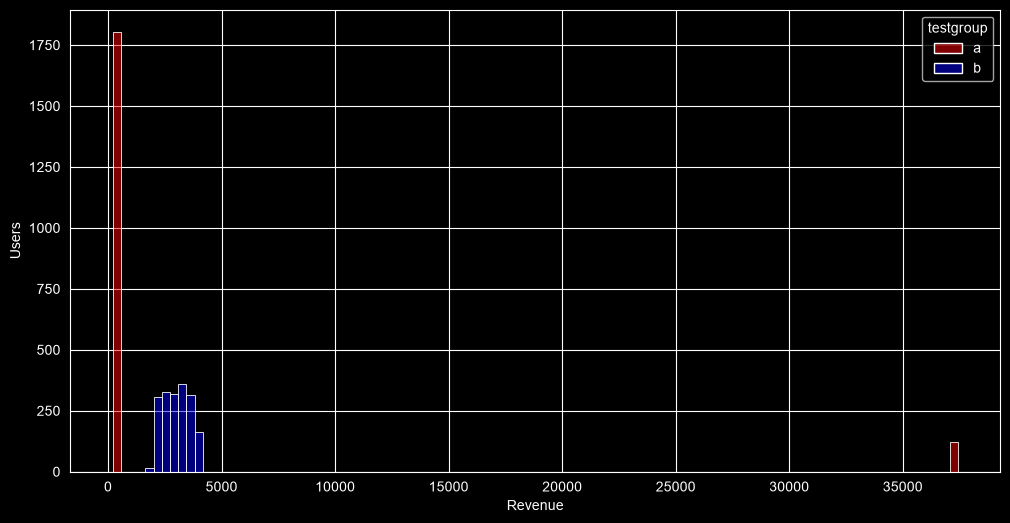

In [67]:
paying_users = df_ab[df_ab['revenue'] > 0]

# 2. Настройка размера графика
plt.figure(figsize=(12, 6))

# 3. Построение гистограммы
sns.histplot(
    data=paying_users,
    x='revenue',
    hue='testgroup',
    palette={'a': 'red', 'b': 'blue'}
)

plt.xlabel('Revenue')
plt.ylabel('Users')
plt.show()

# Retention аналіз

Тут нам треба знайти через скільки йдуть люди після реєстрації, в загалі. Метою є діагностика продукту, для подальшого аналізу, немає сенсу вкладатися в рекламу, якщо користувачі відразу ж йдуть. Для цього нам треба з'єднати таблиці реєстрації з таблицею заходу до додатків.

In [68]:
df_auth.info()

<class 'pandas.DataFrame'>
RangeIndex: 9601013 entries, 0 to 9601012
Data columns (total 2 columns):
 #   Column   Dtype
---  ------   -----
 0   auth_ts  int64
 1   uid      int64
dtypes: int64(2)
memory usage: 146.5 MB


In [69]:
df_reg.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   reg_ts  1000000 non-null  int64
 1   uid     1000000 non-null  int64
dtypes: int64(2)
memory usage: 15.3 MB


## Функція розрахунку Retention матриці

In [70]:
def retention_heatmap(reg_table, auth_table, start_date, end_date):
    # Готуємо дані
    auth_table['time'] = pd.to_datetime(auth_table['auth_ts'], unit='s') # приводимо у потрібний вигляд
    auth_table['day'] = auth_table['time'].dt.to_period('D')
    reg_table['time'] = pd.to_datetime(reg_table['reg_ts'], unit='s')
    reg_table['cohort_day'] = reg_table['time'].dt.to_period('D')

    # Переводимо текстові дати у формат Period для порівняння
    start = pd.Period(start_date, freq='D')
    end = pd.Period(end_date, freq='D')

    # Фільтруємо таблиці
    auth_table = auth_table[(auth_table['day'] >= start) & (auth_table['day'] <= end)]
    reg_table = reg_table[(reg_table['cohort_day'] >= start) & (reg_table['cohort_day'] <= end)]

    # З'єднуємо таблиці, щоб у нас для кожного користувача був його місяць реєстрації
    df_cohort = auth_table.merge(reg_table[['uid', 'cohort_day']], on='uid')

    # Рахуємо для кожної когорти та дня заходу, кількість користувачів
    df_cohort['repeat_visit'] = (df_cohort['day'] - df_cohort['cohort_day']).apply(lambda x: x.n)
    df_cohort_count = df_cohort.groupby(['cohort_day', 'repeat_visit'])['uid'].nunique().reset_index()
    df_cohort_pivot = df_cohort_count.pivot(index='cohort_day', columns='repeat_visit', values='uid')
    retention_table = df_cohort_pivot.divide(df_cohort_pivot[0], axis=0) # ділимо на перший день

    return retention_table.iloc[:, 1:]

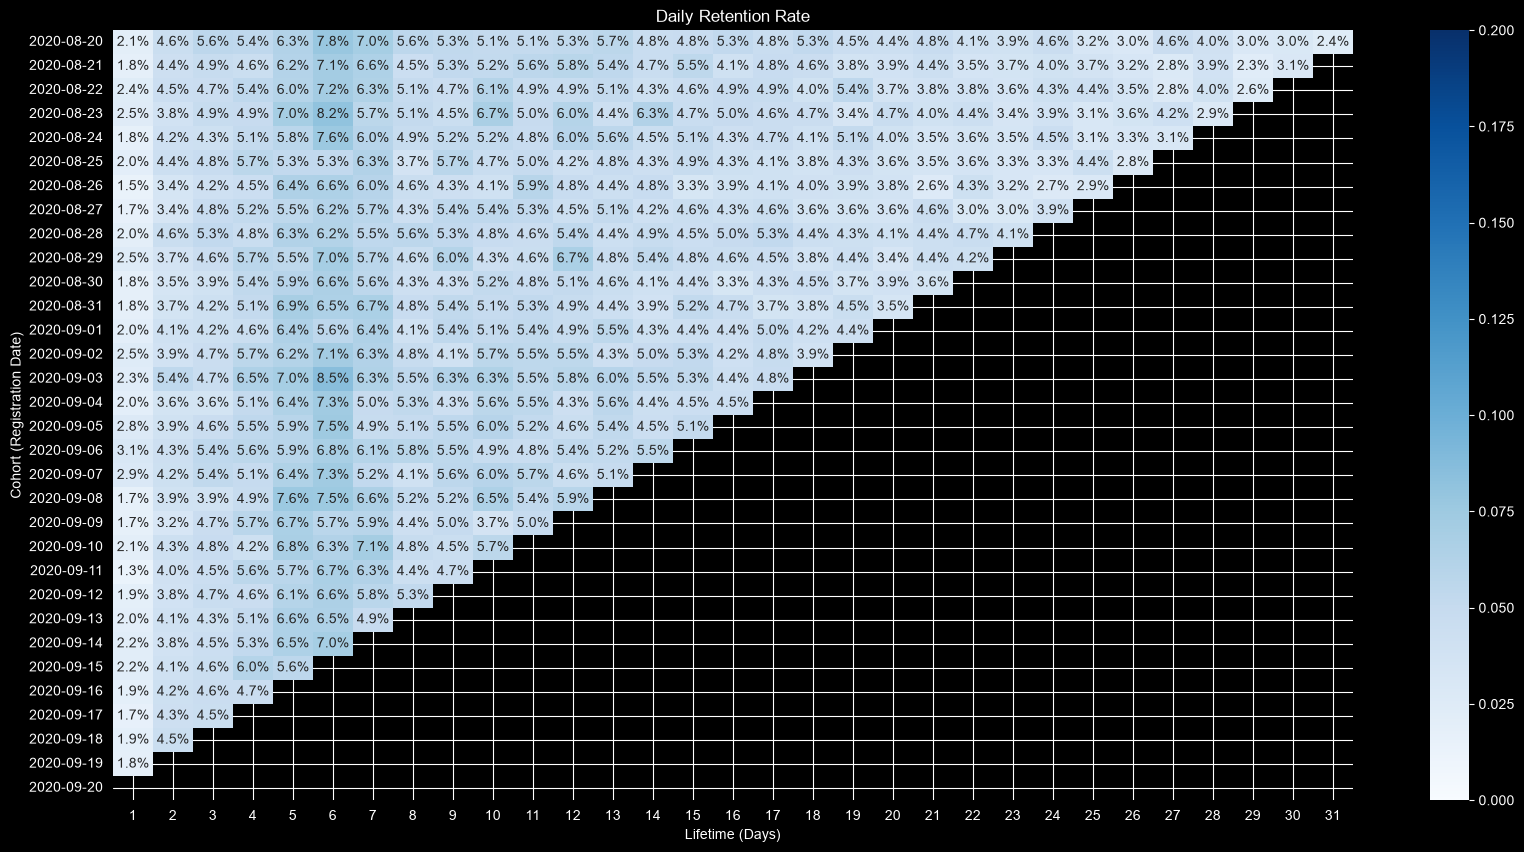

In [71]:
plt.figure(figsize=(20, 10))

sns.heatmap(retention_heatmap(df_reg, df_auth, '2020-08-20', '2020-09-20'), annot=True, fmt='.1%', cmap='Blues', vmin=0.0, vmax=0.2)
plt.title('Daily Retention Rate')
plt.ylabel('Cohort (Registration Date)')
plt.xlabel('Lifetime (Days)')
plt.show()